# BugZero (CodeSage): ML notebook

This notebook builds the machine learning part of BugZero, one step at a time.

| Step | What | Status |
|---|---|---|
| 1 | Get the dataset (PyVul + ordinary functions) | done |
| 2 | CodeBERT embeddings | done |
| 3 | Train classifier (Logistic Regression, compare Gradient Boosting) | done |
| 4 | Evaluate on the test set: Precision, Recall, F1, Confusion Matrix | next |
| 5 | Save the model | to do |

Runs on Google Colab (Runtime > Run all) or locally with Python 3.12.
Step 1 only needs numpy, pandas, matplotlib and scikit-learn.
Step 2 also needs `torch` and `transformers` and a GPU (on Colab: Runtime > Change runtime type > T4 GPU).

## Step 1: Get the dataset

We use **PyVul** (MSR 2026): real vulnerabilities found in Python packages,
collected from GitHub Security Advisories, Snyk and Huntr, and cleaned with GPT-4.

Each record is one vulnerable function, with its code before the fix (`code_before`)
and after the fix (`code_after`). It also lists the other functions changed in the same
fix commit. A second file maps each fix commit to its CWE (the type of weakness).

Our dataset has three kinds of functions:

| Kind | Label | Where it comes from |
|---|---|---|
| vulnerable | 1 | PyVul: the function before the security fix |
| hard safe | 0 | PyVul: other functions changed in the same fix, after the fix |
| ordinary safe | 0 | GitHub: functions in the same files that the fix did not touch (1.6) |

> Haowei Quan, Terry Yue Zhuo, Junjie Wang, Xiao Chen, Xinzhe Li, Xiaoning Du.
> *An Empirical Study of Vulnerabilities in Python Packages and Their Detection.*
> MSR 2026. arXiv:2509.04260. Data: https://github.com/billquan/PyVul

### 1.1 Download the two PyVul files

In [1]:
import os
import json
import urllib.request

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold

# PyVul files on GitHub
BASE_URL = "https://raw.githubusercontent.com/billquan/PyVul/main/dataset/"
FILES = ["function_level_dataset.out", "commits_cwe_map.json"]

os.makedirs("pyvul", exist_ok=True)
for name in FILES:
    path = os.path.join("pyvul", name)
    if not os.path.exists(path):  # download only once
        urllib.request.urlretrieve(BASE_URL + name, path)
    print(name, round(os.path.getsize(path) / 1e6, 1), "MB")

function_level_dataset.out 21.7 MB
commits_cwe_map.json 0.2 MB


### 1.2 Load the records

In [2]:
# each line of the .out file is one JSON record
records = []
with open("pyvul/function_level_dataset.out", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

# commit URL -> CWE id, for example "CWE-79"
with open("pyvul/commits_cwe_map.json", encoding="utf-8") as f:
    cwe_map = json.load(f)

# BugZero is Python only (MVP), so keep only Python records
python_records = [r for r in records if r["programming_language"] == "Python"]

print("All records:   ", len(records))
print("Python records:", len(python_records))
print("Fields:", list(records[0].keys()))

All records:    2173
Python records: 1569
Fields: ['function_name', 'code_before', 'code_after', 'commit_message', 'commit', 'description', 'file_change_id', 'report_link', 'programming_language', 'other_changed_function_in_the_commit', 'gpt_answer']


### 1.3 Build labelled samples from PyVul

* **vulnerable (1)**: `code_before` of each record (the function before it was fixed).
* **hard safe (0)**: the *other* functions changed in the same fix commit, after the fix (`code_after`).

We do **not** use the fixed copy of the same vulnerable function as a safe example.
It is almost the same code (often one line changed), and the PyVul paper shows
models cannot tell such pairs apart. It would only confuse the classifier.

In [3]:
def get_repo(commit_url):
    # "https://github.com/owner/name/commit/abc" -> "owner/name"
    parts = commit_url.split("github.com/")[1].split("/")
    return (parts[0] + "/" + parts[1]).lower()

rows = []

# vulnerable functions first, so they win when we remove duplicates later
for r in python_records:
    rows.append({
        "code": r["code_before"].strip(),
        "label": 1,
        "kind": "vulnerable",
        "repo": get_repo(r["commit"]),
        "commit": r["commit"],
        "cwe": cwe_map.get(r["commit"], "unknown"),
    })

# hard safe: other functions from the same fix commit, after the fix
for r in python_records:
    for other in r["other_changed_function_in_the_commit"]:
        rows.append({
            "code": other["code_after"].strip(),
            "label": 0,
            "kind": "hard_safe",
            "repo": get_repo(r["commit"]),
            "commit": r["commit"],
            "cwe": cwe_map.get(r["commit"], "unknown"),
        })

df = pd.DataFrame(rows)
print("Samples before cleaning:", len(df))
print(df["kind"].value_counts())

Samples before cleaning: 3888
kind
hard_safe     2319
vulnerable    1569
Name: count, dtype: int64


### 1.4 Clean: drop empty code and exact duplicates

In [4]:
df = df[df["code"] != ""]                              # empty code (function was deleted)
df = df.drop_duplicates(subset="code", keep="first")   # same code twice (keeps the vulnerable one)
df = df.reset_index(drop=True)

print("Samples after cleaning:", len(df))
print(df["kind"].value_counts())
print("Projects:", df["repo"].nunique())

Samples after cleaning: 2222
kind
vulnerable    1400
hard_safe      822
Name: count, dtype: int64


Projects: 323


### 1.5 Look at the data

In [5]:
df["lines"] = df["code"].str.count("\n") + 1

print("Median lines:", df.groupby("kind")["lines"].median().to_dict())
print("Starts with 'def':      ", df["code"].str.startswith("def").sum())
print("Starts with 'async def':", df["code"].str.startswith("async def").sum())

print("\nTop CWEs in vulnerable functions:")
print(df[df["kind"] == "vulnerable"]["cwe"].value_counts().head(8))

Median lines: {'hard_safe': 20.0, 'vulnerable': 23.5}
Starts with 'def':       2127
Starts with 'async def': 95

Top CWEs in vulnerable functions:
cwe
CWE-79     112
CWE-22      86
CWE-20      65
CWE-400     63
CWE-200     59
CWE-362     54
CWE-601     53
CWE-352     48
Name: count, dtype: int64


In [6]:
# one real vulnerable function: path traversal (CWE-22)
# os.path.join() with user input, and the only check is an assert
# (asserts are removed when Python runs with -O, and "../" is never cleaned)
example = df[df["code"].str.contains("os.path.join(path, *args)", regex=False)].iloc[0]
print(example["repo"], "|", example["cwe"], "| label =", example["label"])
print()
print(example["code"])

ikus060/rdiffweb | CWE-22 | label = 1

def static(path):
    """
    Create a page handler to serve static files. Disable authentication.
    """
    assert isinstance(path, str)
    assert os.path.exists(path), "%r doesn't exists" % path
    content_type = None
    if os.path.isfile(path):
        # Set content-type based on filename extension
        ext = ""
        i = path.rfind('.')
        if i != -1:
            ext = path[i:].lower()
        content_type = mimetypes.types_map.get(ext, None)  # @UndefinedVariable

    @cherrypy.expose
    @cherrypy.tools.auth_form(on=False)
    @cherrypy.tools.sessions(on=False)
    @cherrypy.tools.secure_headers(on=False)
    def handler(*args, **kwargs):
        if cherrypy.request.method not in ('GET', 'HEAD'):
            return None
        filename = os.path.join(path, *args)
        assert filename.startswith(path)
        if not os.path.isfile(filename):
            return None
        return serve_file(filename, content_type)

    retu

### 1.6 Add ordinary safe functions

With only the two groups above, our first model in Step 3 was barely better than
guessing (ROC-AUC 0.56). The hard safe functions are neighbours of the bug: same
commit, usually the same file and topic. But in the app, users upload **ordinary** code.

So we add a third group, **ordinary safe** (label 0): functions in the same files
that the security fix did **not** touch. The script `ml/datasets/fetch_ordinary_functions.py`
downloaded about 26,000 of them from GitHub once (it needs a GitHub token).
Here we pick a fair sample:

1. Drop every function whose name was changed by **any** security fix in that project,
   because it might be the vulnerable one in another commit.
2. For every vulnerable function, pick one ordinary function from the **same project**
   with the **closest length**. Then the model can't win by learning a project's style
   or by learning "long function = vulnerable".

In [7]:
# made by ml/datasets/fetch_ordinary_functions.py (on Colab: read it from our GitHub repo)
ORDINARY_FILE = "../datasets/ordinary_functions.csv.gz"
if not os.path.exists(ORDINARY_FILE):
    ORDINARY_FILE = "https://raw.githubusercontent.com/Diyap235/Bugzero/main/ml/datasets/ordinary_functions.csv.gz"
pool = pd.read_csv(ORDINARY_FILE)
print("Ordinary functions downloaded:", len(pool))

# 1. names of all functions that any fix touched, per project
touched = set()
for r in python_records:
    repo = get_repo(r["commit"])
    touched.add((repo, r["function_name"].split(".")[-1]))
    for other in r["other_changed_function_in_the_commit"]:
        touched.add((repo, other["function_name"].split(".")[-1]))

pool["name"] = pool["code"].str.extract(r"^(?:async\s+)?def\s+(\w+)")[0]
never_touched = [(repo, name) not in touched for repo, name in zip(pool["repo"], pool["name"])]
pool = pool[never_touched]
pool = pool[~pool["code"].isin(set(df["code"]))]  # not already in our data
print("Never touched by a fix:", len(pool))

# 2. one ordinary function per vulnerable function: same project, closest length
picked = []
for repo, vulnerable in df[df["kind"] == "vulnerable"].groupby("repo"):
    candidates = pool[pool["repo"] == repo].sample(frac=1, random_state=42)  # shuffle, so ties are random
    for n_lines in vulnerable["lines"]:
        if len(candidates) == 0:
            break  # this project has no more ordinary functions
        closest = (candidates["lines"] - n_lines).abs().idxmin()
        picked.append(closest)
        candidates = candidates.drop(closest)

chosen = pool.loc[picked]
ordinary = pd.DataFrame({
    "code": chosen["code"],
    "label": 0,
    "kind": "ordinary_safe",
    "repo": chosen["repo"],
    "commit": chosen["commit"],
    "cwe": "none",
    "lines": chosen["lines"],
})
df = pd.concat([df, ordinary], ignore_index=True)

print("Ordinary safe added:", len(ordinary), "from", ordinary["repo"].nunique(), "projects")
print("\nAll samples:", len(df))
print(df["kind"].value_counts())
print("\nMedian lines:", df.groupby("kind")["lines"].median().to_dict())

Ordinary functions downloaded: 25859
Never touched by a fix: 23706


Ordinary safe added: 1363 from 303 projects

All samples: 3585
kind
vulnerable       1400
ordinary_safe    1363
hard_safe         822
Name: count, dtype: int64

Median lines: {'hard_safe': 20.0, 'ordinary_safe': 21.0, 'vulnerable': 23.5}


### 1.7 Project-wise train/test split

Functions from the same project share coding style. If one project were in both
train and test, the model could score well just by remembering the style.
So each project goes **only** to train or **only** to test (`groups = repo`),
while keeping the vulnerable/safe ratio similar (`Stratified`).
We use the first of 5 folds as the test set (about 20%).

In [8]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(df, df["label"], groups=df["repo"]))

df["split"] = "train"
df.loc[test_idx, "split"] = "test"

for name in ["train", "test"]:
    part = df[df["split"] == name]
    n = part["kind"].value_counts()
    print(f"{name}: {len(part)} samples ({n['vulnerable']} vulnerable, {n['hard_safe']} hard safe, "
          f"{n['ordinary_safe']} ordinary safe), {part['repo'].nunique()} projects")

shared = set(df[df["split"] == "train"]["repo"]) & set(df[df["split"] == "test"]["repo"])
print("Projects in both train and test:", len(shared))

train: 2878 samples (1115 vulnerable, 684 hard safe, 1079 ordinary safe), 282 projects
test: 707 samples (285 vulnerable, 138 hard safe, 284 ordinary safe), 41 projects
Projects in both train and test: 0


### 1.8 Charts

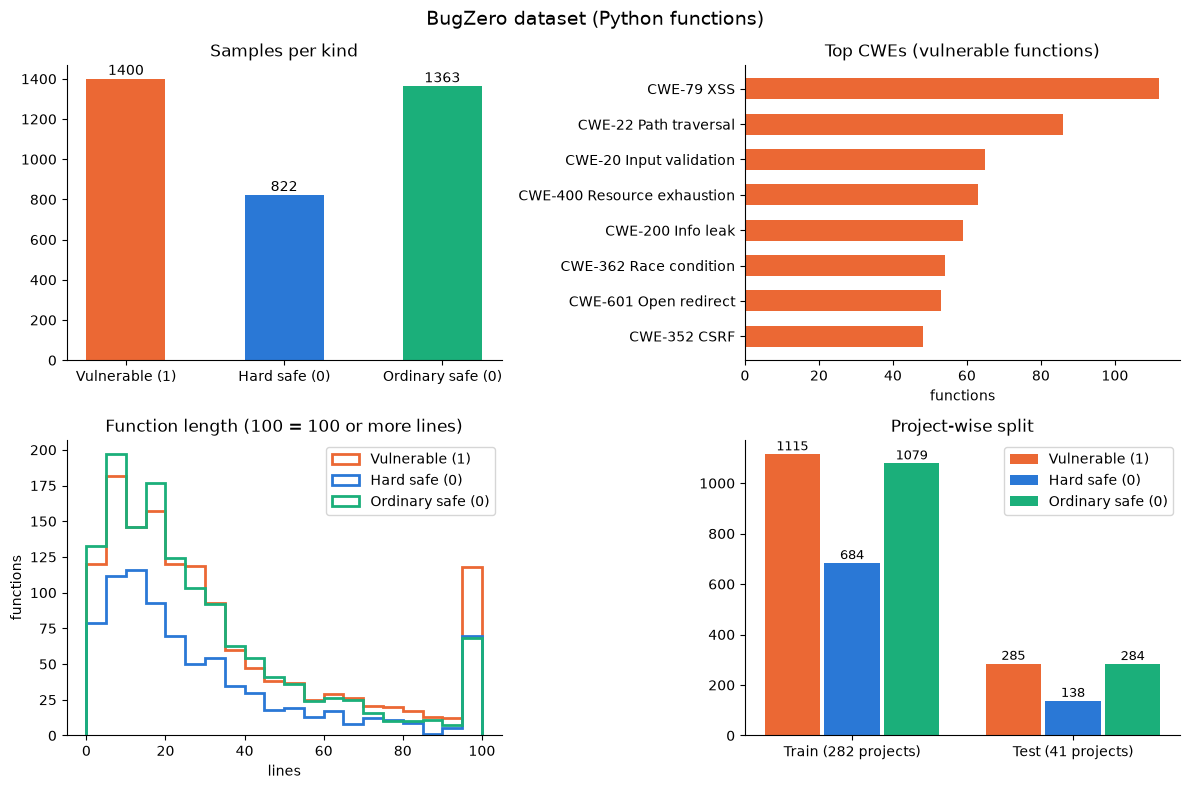

In [9]:
KINDS = ["vulnerable", "hard_safe", "ordinary_safe"]
COLORS = {"vulnerable": "#eb6834", "hard_safe": "#2a78d6", "ordinary_safe": "#1baf7a"}
NAMES = {"vulnerable": "Vulnerable (1)", "hard_safe": "Hard safe (0)", "ordinary_safe": "Ordinary safe (0)"}
CWE_NAMES = {"CWE-79": "XSS", "CWE-22": "Path traversal", "CWE-20": "Input validation",
             "CWE-400": "Resource exhaustion", "CWE-200": "Info leak", "CWE-362": "Race condition",
             "CWE-601": "Open redirect", "CWE-352": "CSRF"}

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# (a) how many samples of each kind
counts = [(df["kind"] == k).sum() for k in KINDS]
ax[0, 0].bar([NAMES[k] for k in KINDS], counts, color=[COLORS[k] for k in KINDS], width=0.5)
for i, c in enumerate(counts):
    ax[0, 0].text(i, c + 20, str(c), ha="center")
ax[0, 0].set_title("Samples per kind")

# (b) most common weakness types in vulnerable functions
top = df[df["kind"] == "vulnerable"]["cwe"].value_counts().head(8)[::-1]
names = [f"{c} {CWE_NAMES.get(c, '')}" for c in top.index]
ax[0, 1].barh(names, top.values, color=COLORS["vulnerable"], height=0.6)
ax[0, 1].set_title("Top CWEs (vulnerable functions)")
ax[0, 1].set_xlabel("functions")

# (c) function length per kind (cut at 100 lines so the chart is readable)
bins = range(0, 101, 5)
for k in KINDS:
    ax[1, 0].hist(df[df["kind"] == k]["lines"].clip(upper=100), bins=bins,
                  histtype="step", linewidth=2, color=COLORS[k], label=NAMES[k])
ax[1, 0].set_title("Function length (100 = 100 or more lines)")
ax[1, 0].set_xlabel("lines")
ax[1, 0].set_ylabel("functions")
ax[1, 0].legend()

# (d) train and test, by kind
splits = ["train", "test"]
for j, k in enumerate(KINDS):
    values = [((df["split"] == s) & (df["kind"] == k)).sum() for s in splits]
    xs = [i + (j - 1) * 0.27 for i in range(len(splits))]
    ax[1, 1].bar(xs, values, width=0.25, color=COLORS[k], label=NAMES[k])
    for x, v in zip(xs, values):
        ax[1, 1].text(x, v + 15, str(v), ha="center", fontsize=9)
labels = []
for s in splits:
    n_projects = df[df["split"] == s]["repo"].nunique()
    labels.append(f"{s.title()} ({n_projects} projects)")
ax[1, 1].set_xticks(range(len(splits)))
ax[1, 1].set_xticklabels(labels)
ax[1, 1].set_title("Project-wise split")
ax[1, 1].legend()

for a in ax.flat:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

fig.suptitle("BugZero dataset (Python functions)", fontsize=14)
plt.tight_layout()
plt.savefig("dataset_overview.png", dpi=150)
plt.show()

### 1.9 Save the dataset

In [10]:
df[["code", "label", "kind", "repo", "commit", "cwe", "split"]].to_csv("bugzero_dataset.csv", index=False)
print("Saved bugzero_dataset.csv:", len(df), "rows")

Saved bugzero_dataset.csv: 3585 rows


### Step 1 summary

* **3,585 Python functions** from 323 projects: **1,400 vulnerable**, 822 hard safe and 1,363 ordinary safe.
* **Train: 2,878** (282 projects). **Test: 707** (41 projects). No project is in both.
* Most common weaknesses: XSS, path traversal, input validation, resource exhaustion.
* All three kinds have a similar length (median 23.5, 20 and 21 lines), so length
  gives almost nothing away.

**Why ML and not only Bandit?** In the PyVul paper, Bandit found only 5.3% of the
vulnerabilities (10 of 189 commits) and gave about 1,709 warnings per sample.
A static tool alone misses most real bugs and floods the user with noise.
For comparison, the paper's best result (fine-tuned GPT-3.5) reached an F1 of 71.6%.

**Next: Step 2**, turn each function into 768 numbers with CodeBERT.

## Step 2: CodeBERT embeddings

A classifier can't read code, it only understands numbers. **CodeBERT**
(`microsoft/codebert-base`) is a model already trained on millions of functions in
6 languages, Python included. We use it as a translator: code in, numbers out.

How one function becomes 768 numbers:

1. We collapse extra spaces, then the **tokenizer** cuts the code into small pieces (tokens), at most 512.
2. **CodeBERT** gives 768 numbers for every token, based on the tokens around it.
3. **Mean pooling**: we average those token vectors (skipping padding), so every
   function, long or short, ends up as exactly **768 numbers**. This is its *embedding*.

CodeBERT is **frozen**: we don't train it, we only use it (`eval()` mode, `torch.no_grad()`).
Only the small classifier in Step 3 learns from our data.

### 2.1 Load the dataset and pick the device

In [11]:
import os
import warnings
os.environ["HF_HUB_VERBOSITY"] = "error"             # hide Hugging Face download messages
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"  # hide a Windows-only cache warning
warnings.filterwarnings("ignore")                    # hide other library warnings

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModel
from transformers.utils import logging as hf_logging
hf_logging.disable_progress_bar()

df = pd.read_csv("bugzero_dataset.csv")
train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)
print("Train:", len(train_df), " Test:", len(test_df))

# GPU if we have one (Colab T4 or a local NVIDIA card), else CPU (much slower)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, torch.cuda.get_device_name(0) if device == "cuda" else "")

Train: 2878  Test: 707
Device: cuda NVIDIA GeForce RTX 3050 Laptop GPU


### 2.2 Load CodeBERT (frozen)

In [12]:
MODEL_NAME = "microsoft/codebert-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()  # frozen: we only use the model, we don't train it

n_params = sum(p.numel() for p in model.parameters())
print("CodeBERT parameters:", round(n_params / 1e6), "million")

CodeBERT parameters: 125 million


### 2.3 What the tokenizer does (and why we collapse spaces)

CodeBERT reads at most **512 tokens** per function. Anything after that is cut off.
The tokenizer spends a token on almost every indentation space (the `Ġ` pieces below),
so long Python functions waste a lot of that room on spaces.

Fix: turn every run of spaces, tabs and newlines into one space before tokenizing.
This is the same cleaning Microsoft's CodeXGLUE benchmark uses before CodeBERT for
bug detection. We lose the indentation, but names and keywords (which carry the
meaning) all stay. The CSV keeps the original code; we only clean it here.

In [13]:
def clean_code(code):
    # "def f():\n    return 1"  ->  "def f(): return 1"
    return " ".join(code.split())

small = "def add(a, b):\n    return a + b"
print("Original:", tokenizer.tokenize(small))
print("Cleaned: ", tokenizer.tokenize(clean_code(small)))

# how many of our functions are longer than 512 tokens? (only the first 512 are used)
for name, codes in [("original", df["code"]), ("cleaned", df["code"].apply(clean_code))]:
    lengths = np.array([len(tokenizer(c, verbose=False)["input_ids"]) for c in codes])
    print(f"\n{name}: median {int(np.median(lengths))} tokens, "
          f"longer than 512: {(lengths > 512).sum()} of {len(lengths)} "
          f"({(lengths > 512).mean() * 100:.0f}%)")

Original: ['def', 'Ġadd', '(', 'a', ',', 'Ġb', '):', 'Ċ', 'Ġ', 'Ġ', 'Ġ', 'Ġreturn', 'Ġa', 'Ġ+', 'Ġb']
Cleaned:  ['def', 'Ġadd', '(', 'a', ',', 'Ġb', '):', 'Ġreturn', 'Ġa', 'Ġ+', 'Ġb']



original: median 383 tokens, longer than 512: 1402 of 3585 (39%)



cleaned: median 207 tokens, longer than 512: 649 of 3585 (18%)


### 2.4 Function: code -> 768 numbers (mean pooling)

In [14]:
def get_embeddings(codes, batch_size=16):
    all_vectors = []
    for start in range(0, len(codes), batch_size):
        batch = [clean_code(c) for c in codes[start:start + batch_size]]
        tokens = tokenizer(batch, padding=True, truncation=True,
                           max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():  # no training, so no gradients needed
            output = model(**tokens)

        # mean pooling: average the token vectors, but skip the padding tokens
        mask = tokens["attention_mask"].unsqueeze(-1).float()
        summed = (output.last_hidden_state * mask).sum(dim=1)
        vectors = summed / mask.sum(dim=1)

        all_vectors.append(vectors.cpu().numpy())
    return np.vstack(all_vectors)

### 2.5 Quick check: similar code gets similar numbers

`add` and `sum_two` do the same thing with different names. `read_file` does something else.
Cosine similarity is 1.0 for identical directions, lower for different ones.
All code looks fairly alike to CodeBERT, so every score is close to 1.
What matters is which pair scores **higher**.

In [15]:
a = "def add(a, b):\n    return a + b"
b = "def sum_two(x, y):\n    result = x + y\n    return result"
c = "def read_file(name):\n    return open(name).read()"

va, vb, vc = get_embeddings([a, b, c])

def cosine(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

print("add vs sum_two  :", round(cosine(va, vb), 3))
print("add vs read_file:", round(cosine(va, vc), 3))

add vs sum_two  : 0.986
add vs read_file: 0.967


### 2.6 Embed all functions and save

In [16]:
start = time.time()
X_train = get_embeddings(train_df["code"].tolist())
X_test = get_embeddings(test_df["code"].tolist())
print("Time:", round(time.time() - start), "seconds")

print("X_train:", X_train.shape)  # (functions, 768)
print("X_test: ", X_test.shape)

# save so we never have to run CodeBERT again for training
np.save("train_embeddings.npy", X_train)
np.save("test_embeddings.npy", X_test)
print("Saved train_embeddings.npy and test_embeddings.npy")

Time: 345 seconds
X_train: (2878, 768)
X_test:  (707, 768)
Saved train_embeddings.npy and test_embeddings.npy


### 2.7 A look at the embeddings in 2D

768 numbers can't be drawn, so PCA squeezes them down to 2 for a picture.
A lot of information is lost on the way, so heavy overlap here is normal.
The classifier in Step 3 works with all 768 numbers.

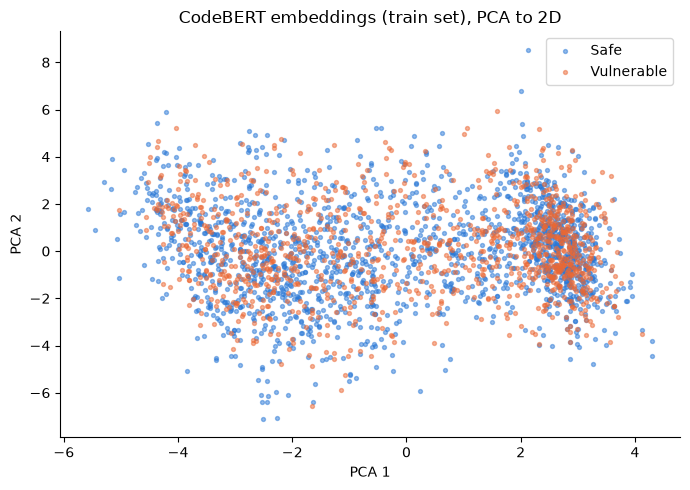

In [17]:
from sklearn.decomposition import PCA

SAFE_COLOR = "#2a78d6"   # same colors as Step 1
VULN_COLOR = "#eb6834"

points = PCA(n_components=2, random_state=42).fit_transform(X_train)
y_train = train_df["label"].values

plt.figure(figsize=(7, 5))
plt.scatter(points[y_train == 0, 0], points[y_train == 0, 1], s=8, alpha=0.5, color=SAFE_COLOR, label="Safe")
plt.scatter(points[y_train == 1, 0], points[y_train == 1, 1], s=8, alpha=0.5, color=VULN_COLOR, label="Vulnerable")
plt.title("CodeBERT embeddings (train set), PCA to 2D")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("embeddings_pca.png", dpi=150)
plt.show()

### Step 2 summary

* Every function is now **768 numbers** from frozen CodeBERT (spaces collapsed, max 512 tokens, mean pooling).
* Collapsing spaces cut the share of functions that don't fit in 512 tokens from 39% to 18%.
* Saved: `train_embeddings.npy` (2,878 x 768) and `test_embeddings.npy` (707 x 768),
  in the same order as the rows in `bugzero_dataset.csv`.
* CodeBERT is the slow part. From now on we only load these files, so training is fast.

**Next: Step 3**, train a Logistic Regression classifier on these numbers.

## Step 3: Train the classifier

**Logistic Regression** gives each of the 768 numbers a weight, adds everything up,
and squeezes the total into a probability between 0 and 1. That probability
(times 100) is the **confidence %** the app will show.

The pieces of our pipeline:

* `StandardScaler`: puts all 768 numbers on the same scale, so no single number dominates.
* `class_weight="balanced"`: our classes are not the same size; this makes the model
  care about both classes equally.
* `C`: how much the model may bend to fit the training data. A small `C` gives a
  simpler model that memorises less. We try several values and keep the best.

**How we choose, without touching the test set.** The test set is the final exam in
Step 4, so we don't look at it now. Instead we use **cross-validation by project**
(`GroupKFold`): split the training projects into 5 groups, train on 4, check on the
5th, and repeat 5 times. Every check uses projects the model has not seen.

**Scores we use:**

* **ROC-AUC**: how well the model ranks vulnerable functions above safe ones.
  0.5 = guessing, 1.0 = perfect. It does not depend on where we put the 50% cut-off.
* **Macro F1**: F1 for safe and F1 for vulnerable, averaged. The model has to be good at
  both. (F1 of the vulnerable class alone can look good for a model that just says
  "vulnerable" to everything.)

### 3.1 Load the embeddings

In [18]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupKFold, GridSearchCV, cross_validate

df = pd.read_csv("bugzero_dataset.csv")
train_df = df[df["split"] == "train"].reset_index(drop=True)

X_train = np.load("train_embeddings.npy")   # (functions, 768) from Step 2
y_train = train_df["label"].values
groups = train_df["repo"].values             # for cross-validation by project

print("X_train:", X_train.shape)
print("Vulnerable:", (y_train == 1).sum(), " Safe:", (y_train == 0).sum())

cv = GroupKFold(n_splits=5)

X_train: (2878, 768)
Vulnerable: 1115  Safe: 1763


### 3.2 Baselines: what does "no real learning" score?

A model is only good if it beats simple tricks:

* **Always guess the bigger class** (here: always "safe").
* **Function length only**: a model that only knows how many lines the function has.
* **TF-IDF word counts**: a classic text model that counts words like `open`, `request`,
  `html` without understanding the code. It shows what CodeBERT adds.

In [19]:
results = []

def evaluate(name, model, X):
    scores = cross_validate(model, X, y_train, groups=groups, cv=cv, scoring=["roc_auc", "f1_macro"])
    auc = scores["test_roc_auc"].mean()
    f1 = scores["test_f1_macro"].mean()
    results.append({"model": name, "ROC-AUC": round(auc, 3), "macro F1": round(f1, 3)})
    print(f"{name:35s} ROC-AUC {auc:.3f}   macro F1 {f1:.3f}")

evaluate("Always guess the bigger class", DummyClassifier(strategy="most_frequent"), X_train)

log_lines = np.log(train_df["code"].str.count("\n").values + 1).reshape(-1, 1)
evaluate("Function length only", LogisticRegression(class_weight="balanced"), log_lines)

tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r"[A-Za-z_][A-Za-z0-9_]*", min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000)),
])
evaluate("TF-IDF words + Logistic Regression", tfidf, train_df["code"])

Always guess the bigger class       ROC-AUC 0.500   macro F1 0.380


Function length only                ROC-AUC 0.530   macro F1 0.517


TF-IDF words + Logistic Regression  ROC-AUC 0.594   macro F1 0.563


### 3.3 CodeBERT + Logistic Regression: pick the best `C`

In [20]:
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=3000)),
])

search = GridSearchCV(lr, {"clf__C": [0.0003, 0.001, 0.003, 0.01, 0.1, 1]}, scoring="roc_auc", cv=cv)
search.fit(X_train, y_train, groups=groups)

table = pd.DataFrame({
    "C": search.cv_results_["param_clf__C"],
    "ROC-AUC": search.cv_results_["mean_test_score"].round(3),
    "+/-": search.cv_results_["std_test_score"].round(3),
})
print(table.to_string(index=False))

best_C = search.best_params_["clf__C"]
print("\nBest C:", best_C)

lr.set_params(clf__C=best_C)
evaluate("CodeBERT + Logistic Regression", lr, X_train)

     C  ROC-AUC   +/-
0.0003    0.594 0.023
0.0010    0.592 0.026
0.0030    0.586 0.027
0.0100    0.575 0.025
0.1000    0.559 0.017
1.0000    0.547 0.010

Best C: 0.0003


CodeBERT + Logistic Regression      ROC-AUC 0.594   macro F1 0.557


### 3.4 Compare: CodeBERT + Gradient Boosting

Gradient Boosting builds many small decision trees, each one fixing the mistakes of
the ones before. It can learn more complicated patterns than Logistic Regression,
but it is slower and easier to over-fit on a small dataset.
`HistGradientBoostingClassifier` is scikit-learn's fast version; `max_features=0.3`
lets each split look at 30% of the 768 numbers, which makes it faster.

In [21]:
start = time.time()
gb = HistGradientBoostingClassifier(class_weight="balanced", max_features=0.3, random_state=42)
evaluate("CodeBERT + Gradient Boosting", gb, X_train)
print("Time:", round(time.time() - start), "seconds")

CodeBERT + Gradient Boosting        ROC-AUC 0.578   macro F1 0.535
Time: 296 seconds


### 3.5 All models side by side

                             model  ROC-AUC  macro F1
     Always guess the bigger class    0.500     0.380
              Function length only    0.530     0.517
TF-IDF words + Logistic Regression    0.594     0.563
    CodeBERT + Logistic Regression    0.594     0.557
      CodeBERT + Gradient Boosting    0.578     0.535


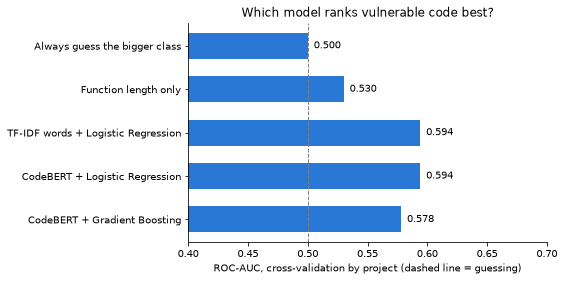

In [22]:
summary = pd.DataFrame(results)
print(summary.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(summary["model"][::-1], summary["ROC-AUC"][::-1], color="#2a78d6", height=0.6)
for y, v in enumerate(summary["ROC-AUC"][::-1]):
    plt.text(v + 0.005, y, f"{v:.3f}", va="center")
plt.axvline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlim(0.4, 0.7)
plt.xlabel("ROC-AUC, cross-validation by project (dashed line = guessing)")
plt.title("Which model ranks vulnerable code best?")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

### 3.6 Train the final model on the whole train set

We keep **CodeBERT + Logistic Regression**: it shares the best ROC-AUC (0.594) with TF-IDF,
and Gradient Boosting was both worse (0.578) and much slower (about 5 minutes against seconds).
TF-IDF scoring the same tells us that frozen CodeBERT adds little over counting words on this data.
We keep CodeBERT + Logistic Regression because it is the method planned for BugZero,
and Step 4 compares both on the test set.
It is also the easiest to explain: every one of the 768 numbers has one weight.
Now we train it once more on all training functions. The test set is still untouched.

In [23]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=3000, C=best_C)),
])
final_model.fit(X_train, y_train)

print("Final model: CodeBERT + Logistic Regression, C =", best_C)
print("Trained on", len(y_train), "functions")

# example: confidence for the first 3 training functions
probs = final_model.predict_proba(X_train[:3])[:, 1]
for p, label in zip(probs, y_train[:3]):
    print(f"  confidence vulnerable = {round(p * 100)}%   (real label: {label})")

Final model: CodeBERT + Logistic Regression, C = 0.0003
Trained on 2878 functions
  confidence vulnerable = 51%   (real label: 1)
  confidence vulnerable = 53%   (real label: 1)
  confidence vulnerable = 54%   (real label: 1)


### Step 3 summary

* Cross-validation by project on 2,878 training functions from 282 projects.
* **CodeBERT + Logistic Regression** (C = 0.0003): **ROC-AUC 0.594**, macro F1 0.557.
  Better than guessing (0.500) and function length (0.530), but not by much.
* **TF-IDF word counts** score the same (0.594), so frozen CodeBERT adds little over counting words here.
* **Gradient Boosting** is worse (0.578) and about 5 minutes slower, so we keep Logistic Regression.
* The best `C` is the smallest one we tried: the model only works when it is kept very simple,
  a sign that the signal in the data is weak.
* The model is unsure: most of its confidences sit between about 36% and 61%.
  This matches the PyVul paper: finding vulnerable Python functions is a hard problem.

**Next: Step 4**, the final exam: run the model on the test set (projects it has never
seen) and report Precision, Recall, F1 and the Confusion Matrix, separately for
ordinary and hard safe code.